In [ ]:
from google.colab import files
upload=files.upload()

Saving salary_prediction_data.csv to salary_prediction_data (1).csv


       Name    Education  Experience  Location Job_Title  Age  Gender  \
0    Rajesh  High School           8     Urban   Manager   63    Male   
1    Suresh          PhD          11  Suburban  Director   59    Male   
2     Priya     Bachelor          28  Suburban   Manager   61  Female   
3    Harish  High School          29     Rural  Director   45    Male   
4    Swathi          PhD          25     Urban   Analyst   26  Female   
..      ...          ...         ...       ...       ...  ...     ...   
194  Deepak  High School           4  Suburban  Director   56    Male   
195  Mahesh  High School          23  Suburban  Director   39    Male   
196   Vidya  High School          29     Urban  Engineer   52  Female   
197  Iniyan     Bachelor           6  Suburban  Director   47    Male   
198  Swathi       Master          27     Rural   Manager   46  Female   

           Salary  
0     84620.05366  
1    142591.25590  
2     97800.25540  
3     96834.67128  
4    132157.78620  
.. 

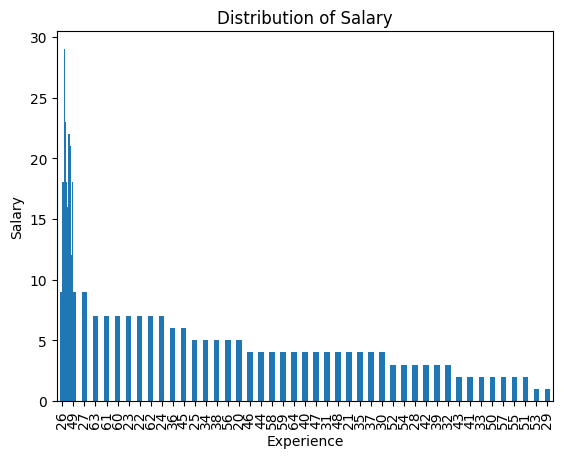

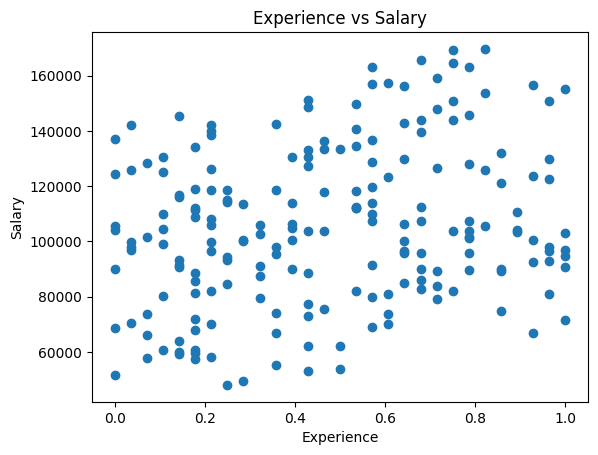

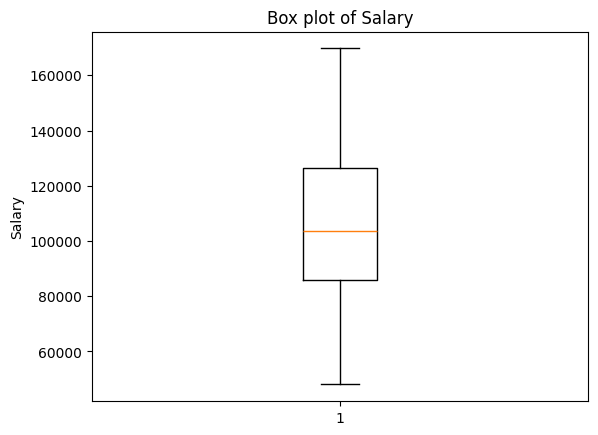


Predicted values:
[ 59366.90641 123672.4124  132357.1074  107222.1266  165810.5594
  59366.90641 164542.837   133614.3213  115954.1188  156312.9362
 137005.642   142122.6673   73043.43575 113727.8966  156729.0839
  81462.71867 100622.2374  151013.4005   80007.84721 123672.4124
 145434.5344  100038.768    49515.33137  91289.99587 136608.8081
  91289.99587 102786.6231  134560.193    59734.10574  92450.57242
  82628.1483   82972.13701  95422.43442 118509.6286   95804.26144
  89948.55569  49515.33137  55066.11435 118799.4401  115954.1188 ]
[ 59366.90641 123672.4124  132357.1074  107222.1266  165810.5594
  59366.90641 164542.837   133614.3213  115954.1188  156312.9362
 137005.642   142122.6673   73043.43575 113727.8966  156729.0839
  81462.71867 100622.2374  151013.4005   80007.84721 123672.4124
 145434.5344  100038.768    49515.33137  91289.99587 136608.8081
  91289.99587 102786.6231  134560.193    59734.10574  92450.57242
  82628.1483   82972.13701  95422.43442 118509.6286   95804.26144


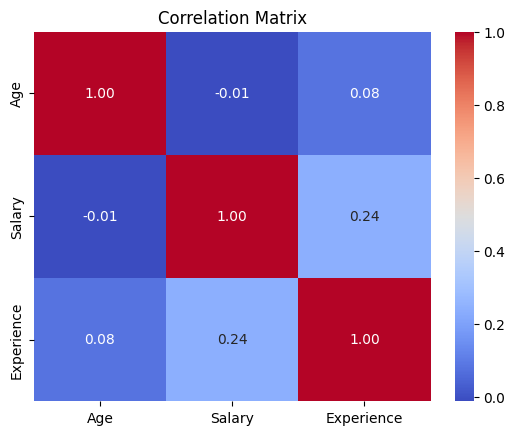

Model training completed successfully.
Intercept: -8.731149137020111e-11

Coefficients:
Age : -6.258565334090842e-14
Salary : 1.0000000000000009
Experience : -2.0394276545321333e-13
Predicted Salary:
[ 84620.05366 142591.2559   97800.2554   96834.67128 132157.7862
 156312.9362  130567.6495  148707.7408   95945.27543 133339.3897
 101164.0924  124251.9871   55066.11435 124972.5088  126139.1367
  81007.19945  60693.92471 103386.0703  140042.1389   86048.11608
  73861.99295 106145.0055  142981.5905   96620.92939  89426.94712
 104762.3985  101747.5408   68635.08828  90550.47942  75559.24411
  87433.49865  57615.23342 126043.1434   73043.43575 134560.193
  95804.26144  99694.53954 153930.9339  151123.3359   81462.71867
 106019.0204  142122.6673   66858.43105  82060.73293 107935.4034
  70251.76628 118799.4401  100369.0235  100038.768   164542.837
  95726.36719  96598.32495  82628.1483   66216.70162 127167.116
 106028.6363  139655.8919  100278.416    67767.86962 148074.0579
 143973.4648  10633

In [87]:
from ctypes import DEFAULT_MODE
from sklearn.preprocessing import LabelEncoder , MinMaxScaler , StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv('/content/salary_prediction_data (1).csv')
df=pd.DataFrame(df)
print(df)

# Data Understanding

print("\nFirst 5 Rows:")
print(df.head())

print("\nLast 5 Rows:")
print(df.tail())

print("\nData Types:")
print(df.dtypes)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
print(df.info)

print("\nDescribe:")
print(df.describe)

print(df[["Name","Age"]])
print(df[df["Age"]=="21"])

print("\nMissing Values:")
print(df.isnull())
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated())
print(df.duplicated().sum())

# Data Preprocessing

df=df.drop_duplicates()
print(df)
print(df["Location"].value_counts())
df["Location"] = df["Location"].replace("unknown",np.nan)
print(pd)
df["Age"]=df["Age"].fillna(df["Age"].mean())
print(DEFAULT_MODE)
df["Location"] = df["Location"].fillna(df["Location"].mode()[0])
print(df)
l=LabelEncoder()
df["Location"]=l.fit_transform(df["Location"])
scaler=MinMaxScaler()
df["Experience"]=scaler.fit_transform(df[["Experience"]])
print(df)

#Statistics

numeric_df = df.select_dtypes(include=np.number)

print("\nMean:")
print(df["Salary"].mean())

print("\nMedian:")
print(df["Salary"].median())

print("\nMode:")
print(df["Salary"].mode())

print("\nVariance:")
print(df["Salary"].var())

print("\nStandard Deviation:")
print(df["Salary"].std())

Salary_range = df["Salary"].max() - df["Salary"].min()
print(Salary_range)




Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)


outliers = df[
    (df["Salary"] < lower) |
    (df["Salary"] > upper)
]

print(outliers)
print(
    df[
        ["Experience", "Age", "Salary"]
    ].corr()
)

# Distribution of Salary

df=pd.DataFrame(df)
print(df.shape)
plt.hist(
    df['Experience']
)
count=df['Age'].value_counts()
count.plot(kind='bar')
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.title('Distribution of Salary')
plt.show()

# Experience vs Salary

plt.scatter(
    df['Experience'],
    df['Salary']
)
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.title('Experience vs Salary')
plt.show()

# Box plot of Salary

plt.boxplot(df['Salary'])
plt.title('Box plot of Salary')
plt.ylabel('Salary')
plt.show()

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
x = df[["Age", "Experience"]]
y = df["Salary"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,

)

model = DecisionTreeRegressor(
    random_state=42
)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print("\nPredicted values:")
print(y_pred)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(y_pred)
from sklearn.metrics import r2_score
accuracy=r2_score(
    y_test,
    y_pred
)
print("Accuracy (R2 Score)",accuracy)


new_student=pd.DataFrame({
    "Age":[7],
    "Experience":[45],
})
correlation_columns = [
    "Age","Salary","Experience"
]
correlation_matrix = df[correlation_columns].corr()
print(correlation_matrix)

import seaborn as sns
sns.heatmap(
    correlation_matrix,annot=True,cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

from sklearn.linear_model import LinearRegression
X = df[
    [
        "Age","Salary","Experience"

    ]
]
y = df["Salary"]

model = LinearRegression()
model.fit(X, y)
print("Model training completed successfully.")

print("Intercept:", model.intercept_)
print("\nCoefficients:")
for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)

predictions = model.predict(X)
print("Predicted Salary:")
print(predictions)

comparison = pd.DataFrame({
    "Actual Salary": y,
    "Predicted Salary": predictions
})
print(comparison)

X = df[
    ["Age","Salary","Experience"]
]

y = df["Salary"]

model = LinearRegression()
model.fit(X, y)

new_order = pd.DataFrame({
    "Age": [30],
    "Experience": [3],
    "Salary": [1000]

})

